# Post 12: What Changes When the Potential Is a Machine-Learned Interatomic Potential?

This notebook is the presentation layer for the twelfth tutorial. The reusable MLIP reliability diagnostics and figure logic live in `src/kups_md_tutorials/`.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.mlip_capstone import load_mlip_summary
from kups_md_tutorials.figures import generate_post12_figures

## Configuration

The smoke and full profiles compare in-domain fcc aluminum, strained-cell, and extrapolative hot regimes. The configured MACE artifact metadata is recorded in the manifest and summary; the current diagnostic is a deterministic surrogate until the final GPU artifact hash is frozen.

In [3]:
for path in [Path("configs/post-12/smoke.json"), Path("configs/post-12/full.json")]:
    config = json.loads(path.read_text())
    print(path)
    print(json.dumps(config["mlip_experiment"], indent=2))

configs/post-12/smoke.json
{
  "material": "fcc_aluminum",
  "temperature_k": 300.0,
  "seed": 2026071412,
  "sample_count": 2500,
  "time_step_fs": 1.0,
  "model_artifact": {
    "name": "mace-mp-0b3-medium.model",
    "repository": "mace-foundations/mace-mp-0",
    "revision": "e291ace",
    "sha256": "2f2be696351ac9e94fbe01cdfb6f017679acdbd2db7645209ef55fec9826b012"
  },
  "cases": [
    {
      "name": "in_domain_fcc",
      "strain": 0.0,
      "thermal_displacement": 0.035,
      "force_noise": 0.035,
      "force_bias": 0.0,
      "uncertainty_scale": 1.0
    },
    {
      "name": "strained_cell",
      "strain": 0.06,
      "thermal_displacement": 0.055,
      "force_noise": 0.07,
      "force_bias": 0.018,
      "uncertainty_scale": 1.4
    },
    {
      "name": "extrapolative_hot",
      "strain": 0.12,
      "thermal_displacement": 0.09,
      "force_noise": 0.135,
      "force_bias": 0.055,
      "uncertainty_scale": 2.0
    }
  ]
}
configs/post-12/full.json
{
  "material

## Committed Full-Profile Diagnostics

The summary records static force and energy errors, NVE-like drift, ensemble temperature drift, extrapolation fractions, uncertainty coverage, neighbor-list risk, and barrier shifts.

In [4]:
summary = load_mlip_summary(Path("results/post-12/full/mlip_summary.json"))
print(f"model: {summary.model_name}")
print(f"repository: {summary.model_repository}")
print(f"revision: {summary.model_revision}")
print(f"sha256: {summary.model_sha256}")
for case in summary.cases:
    print(case.case)
    print(f"  force RMSE: {case.force_rmse:.4f}")
    print(f"  NVE drift: {case.normalized_nve_energy_drift:.4f}")
    print(f"  extrapolation fraction: {case.extrapolation_fraction:.4f}")
    print(f"  uncertainty coverage: {case.uncertainty_coverage_2sigma:.4f}")
    print(f"  barrier shift: {case.free_energy_barrier_shift:.4f}")

model: mace-mp-0b3-medium.model
repository: mace-foundations/mace-mp-0
revision: e291ace
sha256: 2f2be696351ac9e94fbe01cdfb6f017679acdbd2db7645209ef55fec9826b012
in_domain_fcc
  force RMSE: 0.0300
  NVE drift: 0.0026
  extrapolation fraction: 0.0001
  uncertainty coverage: 0.9935
  barrier shift: -0.0000
strained_cell
  force RMSE: 0.0689
  NVE drift: 0.0144
  extrapolation fraction: 0.9945
  uncertainty coverage: 0.9999
  barrier shift: 0.0040
extrapolative_hot
  force RMSE: 0.1530
  NVE drift: 0.0191
  extrapolation fraction: 1.0000
  uncertainty coverage: 1.0000
  barrier shift: 0.0151


## Figure Regeneration

The figure is regenerated from committed compact output files, not from notebook-local simulation code.

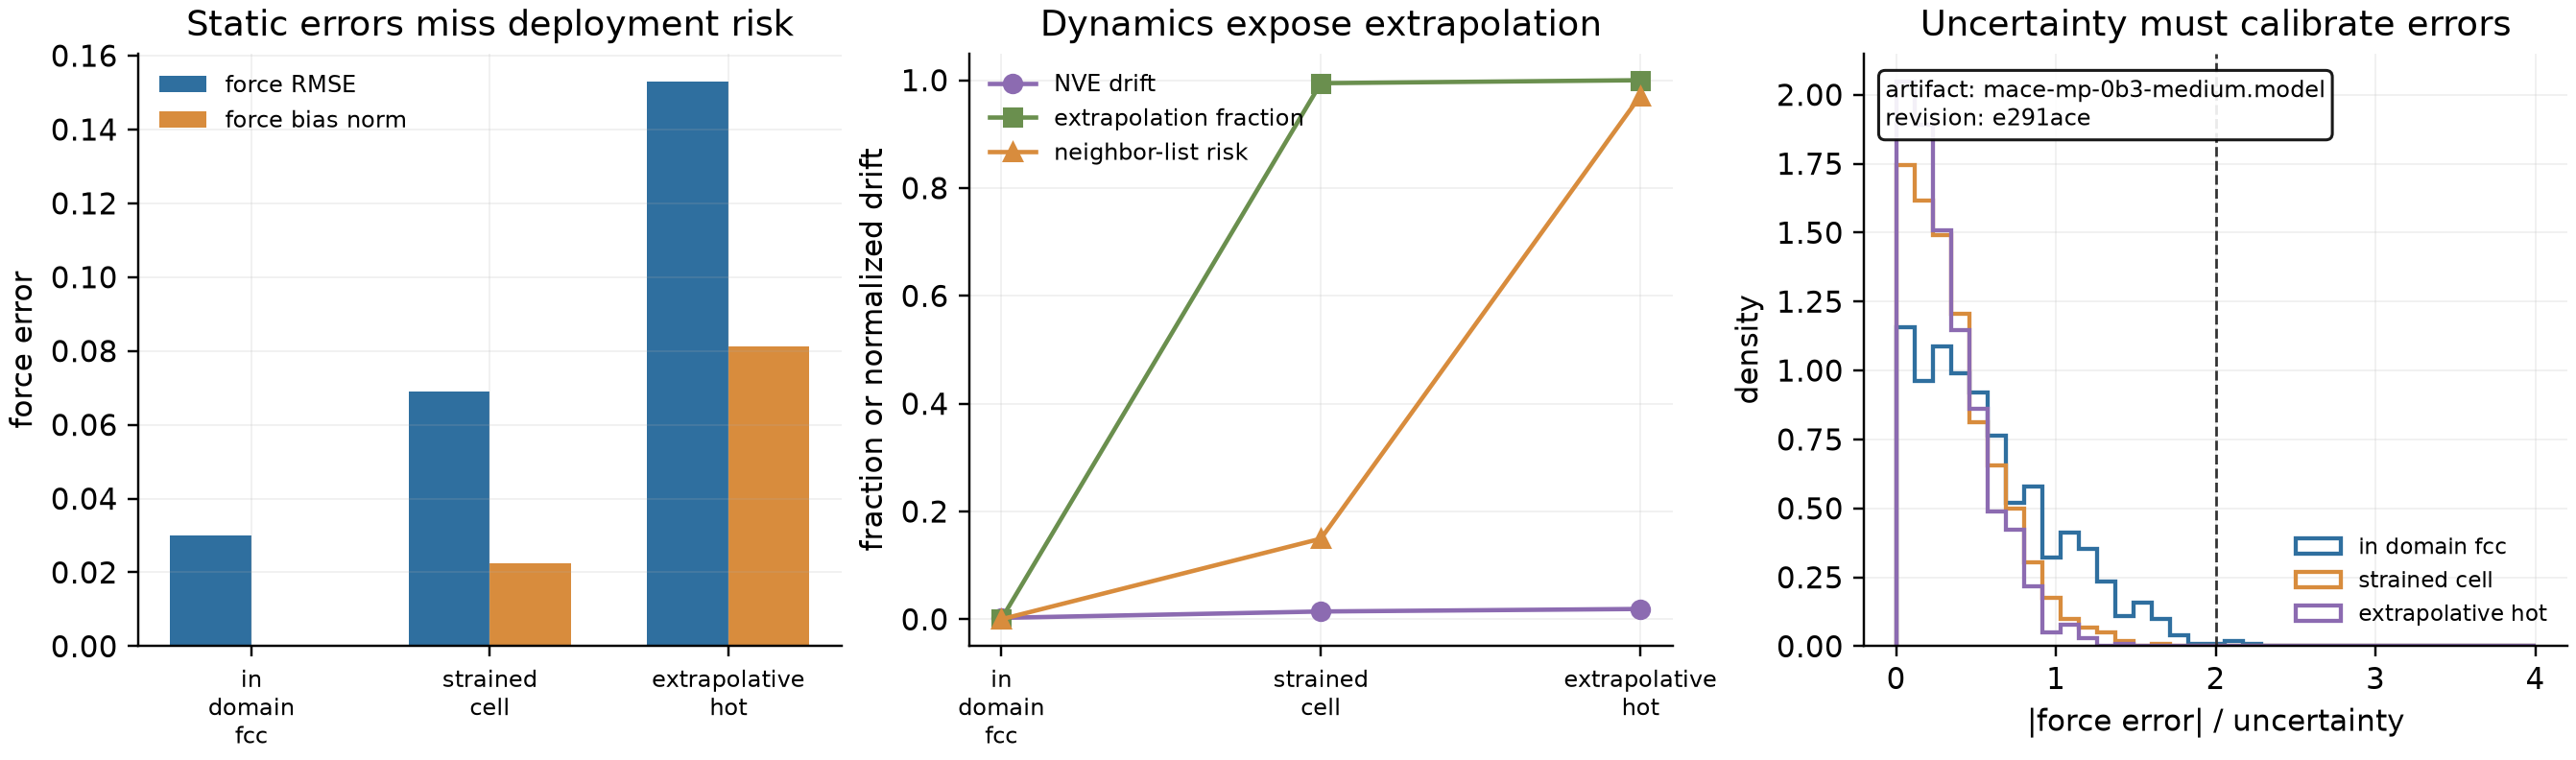

In [5]:
generate_post12_figures(
    result_dir=Path("results/post-12/full"),
    figure_dir=Path("figures/post-12"),
    snapshot_dir=Path("snapshots/post-12"),
    name="mlip_diagnostics_full",
)
display(Image(filename="figures/post-12/mlip_diagnostics_full.png"))